In [69]:
import mujoco as mj
import mujoco.viewer
from pathlib import Path
import time
import numpy as np
import matplotlib.pyplot as plt

In [70]:
# El notebook corre desde notebooks/, asi que el repo es la carpeta padre.
# En vez de asumir cuantos niveles hay que subir, se busca el ancestro que se
# llame "preERP" (case-insensitive: Windows no distingue, pero Path si).

REPO_NAME = "preERP"

# Ruta del XML RELATIVA A LA RAIZ del repo. El export de Fusion2Mujoco vive
# bajo mechanical/step/, no en la raiz.

XML_RELATIVE_PATH = Path("mechanical/mujoco_assets/MyPalletizer260/MyPalletizer260.xml")

def find_repo_root(start: Path, name: str = REPO_NAME) -> Path:
    """Sube desde `start` hasta el ancestro llamado `name`.

    `start` incluido: si ya estas parado en el repo, no sube nada. Si el
    nombre no aparece, cae a la busqueda por marcador (pyproject.toml), que
    es lo que hace que esto siga funcionando si renombras la carpeta.
    """
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if candidate.name.lower() == name.lower():
            return candidate
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(
        f"No se encontro la carpeta '{name}' ni un pyproject.toml subiendo "
        f"desde {start}. Corre el notebook dentro del repo, o fija repo_root a mano."
    )


repo_root = find_repo_root(Path.cwd())
model_path = (repo_root / XML_RELATIVE_PATH).resolve()

if not model_path.is_file():
    raise FileNotFoundError(
        f"Repo root OK ({repo_root}), pero no existe {XML_RELATIVE_PATH} adentro."
        f"Buscado en: {model_path}"
    )

print(f"repo root:  {repo_root}")
print(f"Cargando modelo MuJoCo desde: {model_path}")

model = mj.MjModel.from_xml_path(str(model_path))
data = mj.MjData(model)
mj.mj_resetDataKeyframe(model, data, model.key("home").id)

print(f"Modelo cargado OK -> bodies: {model.nbody}, joints: {model.njnt}, "
      f"geoms: {model.ngeom}, actuadores: {model.nu}")
for j in range(model.njnt):
    print("  joint", j, mj.mj_id2name(model, mj.mjtObj.mjOBJ_JOINT, j))

# Sin `ref` en las juntas, qpos0 = 0: la pose de ensamble ES el cero, y el
# setpoint 0 de los servos pide justamente esa pose (no un salto de 90 deg).
print("qpos0 =", model.qpos0,"\n qpos =", data.qpos)

repo root:  C:\Users\nicoa\Desktop\Universidad\ERP\preERP
Cargando modelo MuJoCo desde: C:\Users\nicoa\Desktop\Universidad\ERP\preERP\mechanical\mujoco_assets\MyPalletizer260\MyPalletizer260.xml
Modelo cargado OK -> bodies: 6, joints: 4, geoms: 26, actuadores: 3
  joint 0 rot
  joint 1 link1
  joint 2 link2
  joint 3 act
qpos0 = [ 1.57   -3.1415 -1.57    1.57  ] 
 qpos = [0. 0. 0. 0.]


In [71]:
# Masa del modelo. Hay DOS totales y los dos son legitimos, asi que conviene
# ver los dos: `base_link` no tiene junta, asi que MuJoCo lo suelda al mundo
# (body_weldid = 0) y su masa no la carga ninguna junta ni la mueve la gravedad.
# Para dimensionar servos o leer pares, el numero que importa es la masa MOVIL.
G = 9.81
movil = np.array([model.body_weldid[b] != 0 for b in range(model.nbody)])

print(f"{'body':<12}{'masa [kg]':>11}   estado")
for b in range(model.nbody):
    if model.body_mass[b] == 0.0:
        continue  # el body `world` pesa 0 por definicion
    name = mj.mj_id2name(model, mj.mjtObj.mjOBJ_BODY, b)
    print(f"{name:<12}{model.body_mass[b]:>11.4f}   "
          + ("movil" if movil[b] else "soldado al mundo"))

m_total = model.body_mass.sum()
m_movil = model.body_mass[movil].sum()
print(f"\nmasa total = {m_total:7.4f} kg  ({m_total * G:6.2f} N)  <- todo el ensamble")
print(f"masa movil = {m_movil:7.4f} kg  ({m_movil * G:6.2f} N)  <- lo que cargan las juntas")
print(f"base fija  = {m_total - m_movil:7.4f} kg  ({(m_total - m_movil) * G:6.2f} N)  <- soldada al mundo")

body          masa [kg]   estado
base_link        0.3063   soldado al mundo
rot              0.1826   movil
link1            0.1834   movil
link2            0.2471   movil
act              0.0495   movil

masa total =  0.9689 kg  (  9.51 N)  <- todo el ensamble
masa movil =  0.6626 kg  (  6.50 N)  <- lo que cargan las juntas
base fija  =  0.3063 kg  (  3.01 N)  <- soldada al mundo


In [72]:
print(np.deg2rad(160))
print(np.deg2rad(90))
print(np.deg2rad(60))

2.792526803190927
1.5707963267948966
1.0471975511965976


In [73]:
SLOWMO_ON = False      # <-- interruptor: False = tiempo real, True = camara lenta
SLOWMO_FACTOR = 10.0   # cuanto mas lento cuando SLOWMO_ON = True
JOINT_DAMPING = 0.05   # N*m*s/rad; 0.0 = caida libre eterna (ver nota arriba)
GRAVITY_ON = True      # False = el brazo se queda como esta, para inspeccionarlo
FPS = 60.0             # frames dibujados por segundo, independiente del slowmo

AXES_VISIBLE = True    # triadas XYZ de los sites al arrancar el visor.
                       # Equivalente sin codigo: tecla 2 adentro del visor.
AXES_GROUP = 2         # los geoms de axis_xyz.xml viven todos en el grupo 2

VMAX_DEG_S = 120.0     # spec del brazo. Unico dato de hardware que tenemos.
RATE_LIMIT_ON = True   # False = escalon crudo, para ver por que hace falta
VMAX = np.radians(VMAX_DEG_S)

slowmo = SLOWMO_FACTOR if SLOWMO_ON else 1.0

model.dof_damping[:] = JOINT_DAMPING
model.opt.gravity[:] = (0, 0, -9.81) if GRAVITY_ON else (0, 0, 0)

# implicitfast mete d(fuerza de actuador)/d(qvel) en el solve implicito. Con
# euler el kv del servo se integra explicito y kv*dt/M pasa el limite de 2.
# Necesario pero NO suficiente: saturado, d(fuerza)/d(vel) = 0 y el termino
# implicito desaparece igual. Por eso las ganancias van dimensionadas por junta
# en el XML, para que kv*dt/M < 2 incluso ahi.
model.opt.integrator = mj.mjtIntegrator.mjINT_IMPLICITFAST
model.vis.quality.shadowsize = 6144

estado = f"ON (x{SLOWMO_FACTOR:g})" if SLOWMO_ON else "OFF (tiempo real)"
print(f"camara lenta: {estado}")
print(f"integrador:   {mj.mjtIntegrator(model.opt.integrator).name}")
print(f"limite de consigna: {'ON' if RATE_LIMIT_ON else 'OFF'} ({VMAX_DEG_S:.0f} deg/s)")
print(f"timestep={model.opt.timestep * 1e3:.0f} ms, dibujo a {FPS:.0f} fps "
      f"-> {1 / FPS / (model.opt.timestep * slowmo):.1f} pasos de fisica por frame")

# Las triadas van en <frame> junto a su site, asi que dibujan EXACTAMENTE el
# marco que lee el sensor. Contar geoms del grupo confirma que el include entro.
n_axes = int((model.geom_group == AXES_GROUP).sum())
print(f"triadas XYZ:  {'ON' if AXES_VISIBLE else 'OFF'} al arrancar "
      f"({n_axes} geoms en el grupo {AXES_GROUP}, {n_axes // 7} sites) "
      f"-> tecla {AXES_GROUP} en el visor")

# Margen de estabilidad por junta: kv*dt/M debe quedar bajo 2 (ver ADR del jitter)
#M = np.zeros((model.nv, model.nv))
#mj.mj_forward(model, data); mj.mj_fullM(model, data, M)
#print(f"\n{'joint':<8}{'kp':>8}{'kv':>8}{'forcerange':>12}{'kv*dt/M':>10}")
#for j in range(model.njnt):
#    a = np.where(model.actuator_trnid[:, 0] == j)[0][0]
#    kp_, kv_ = model.actuator_gainprm[a, 0], -model.actuator_biasprm[a, 2]
#    print(f"{mj.mj_id2name(model, mj.mjtObj.mjOBJ_JOINT, j):<8}{kp_:>8.2f}{kv_:>8.3f}"
#         f"{model.actuator_forcerange[a, 1]:>11.2f} {kv_ * model.opt.timestep / M[j, j]:>9.2f}")

camara lenta: OFF (tiempo real)
integrador:   mjINT_IMPLICITFAST
limite de consigna: ON (120 deg/s)
timestep=2 ms, dibujo a 60 fps -> 8.3 pasos de fisica por frame
triadas XYZ:  ON al arrancar (21 geoms en el grupo 2, 3 sites) -> tecla 2 en el visor


In [74]:
class JitterLog:
    """Graba el estado paso a paso MIENTRAS vos manejas el visor a mano.

    Esta es la diferencia con un test sintetico: el jitter de este modelo lo
    dispara la saturacion de par, y para saturar hace falta un error de
    setpoint grande. Un barrido suave nunca lo toca, tu mano en el slider si.

    Preasigna todo, asi grabar no altera el ritmo del loop: un realloc en
    medio del loop seria justamente el hipo que estamos tratando de medir.
    Si se llena, deja de grabar en vez de crecer.
    """

    def __init__(self, model, max_seconds=120.0):
        n = int(max_seconds / model.opt.timestep) + 16
        self.nj = model.njnt
        self.t = np.zeros(n)
        self.qpos = np.zeros((n, self.nj))
        self.qvel = np.zeros((n, self.nj))
        self.force = np.zeros((n, model.nu))
        self.ctrl = np.zeros((n, model.nu))
        self.i = 0
        self.frames = np.zeros(int(max_seconds * 240) + 16)
        self.fi = 0
        self.forcerange = model.actuator_forcerange.copy()
        self.dt = model.opt.timestep
        self.names = [mj.mj_id2name(model, mj.mjtObj.mjOBJ_JOINT, j)
                      for j in range(self.nj)]

    def step(self, data):
        """Un paso de fisica. Llamar justo despues de mj_step."""
        if self.i >= len(self.t):
            return
        i = self.i
        self.t[i] = data.time
        self.qpos[i] = data.qpos[:self.nj]
        self.qvel[i] = data.qvel[:self.nj]
        self.force[i] = data.actuator_force
        self.ctrl[i] = data.ctrl
        self.i += 1

    def frame(self, t_wall):
        """Un frame dibujado. Llamar justo despues de viewer.sync()."""
        if self.fi < len(self.frames):
            self.frames[self.fi] = t_wall
            self.fi += 1


def diagnostico_jitter(log, win_ms=50.0, figsize=(14, 11)):
    """Seis paneles que, juntos, dicen cual de las tres causas de jitter es.

    Las bandas GRISES verticales marcan saturacion de par. La lectura clave:
    si el chattering (panel 3 en 1.0) cae siempre DENTRO de una banda, la
    causa es la saturacion, no el integrador por si solo. La columna
    "coincide" del veredicto pone ese solapamiento en un numero.
    """
    n = log.i
    if n < 10:
        raise ValueError(f"solo {n} pasos grabados; corre el visor un rato mas")

    t = log.t[:n]
    qpos, qvel = log.qpos[:n], log.qvel[:n]
    force, ctrl = log.force[:n], log.ctrl[:n]
    nj = log.nj

    # saturacion: |f| pegado al tope, con 0.1% de margen para el redondeo
    lim = log.forcerange[:, 1]
    sat = np.abs(force) >= lim[None, :] * 0.999

    # Cambios de signo de qvel en ventana movil. 1.0 = oscila en Nyquist
    # (periodo de DOS pasos), que ninguna fisica hace: eso es el integrador.
    w = max(3, int(win_ms * 1e-3 / log.dt))
    flip = (np.diff(np.sign(qvel), axis=0) != 0).astype(float)
    ker = np.ones(w) / w
    flips = np.vstack([np.convolve(flip[:, j], ker, "same") for j in range(nj)]).T
    t_flip = t[1:]

    fig, ax = plt.subplots(3, 2, figsize=figsize)
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    def shade(a):
        """Sombrea donde CUALQUIER actuador esta saturado."""
        any_sat = sat.any(axis=1)
        if not any_sat.any():
            return
        edges = np.diff(any_sat.astype(int))
        starts = t[np.where(edges == 1)[0] + 1]
        ends = t[np.where(edges == -1)[0] + 1]
        if any_sat[0]:
            starts = np.r_[t[0], starts]
        if any_sat[-1]:
            ends = np.r_[ends, t[-1]]
        for s, e in zip(starts, ends):
            a.axvspan(s, e, color="0.45", alpha=0.16, lw=0, zorder=0)

    # 1) velocidad articular: donde y cuando tiembla. symlog porque el
    #    chattering es ~1e2 rad/s y el movimiento util ~1e-2: en escala
    #    lineal el primero aplasta al segundo y no se ve nada.
    a = ax[0, 0]
    for j in range(nj):
        a.plot(t, qvel[:, j], lw=0.7, color=colors[j], label=log.names[j])
    shade(a)
    a.set_yscale("symlog", linthresh=1e-2)
    a.set(title="1. qvel por junta, symlog (gris = algun actuador saturado)",
          xlabel="t sim [s]", ylabel="rad/s")
    a.legend(fontsize=8, ncol=2)

    # 2) el disparador: par contra su tope
    a = ax[0, 1]
    for j in range(force.shape[1]):
        a.plot(t, force[:, j], lw=0.7, color=colors[j], label=log.names[j])
    for s in (-1, 1):
        a.axhline(s * lim[0], color="red", ls="--", lw=1)
    shade(a)
    a.set(title="2. actuator_force vs forcerange (--)",
          xlabel="t sim [s]", ylabel="N*m")
    a.legend(fontsize=8, ncol=2)

    # 3) el discriminador fisica-vs-numerico
    a = ax[1, 0]
    for j in range(nj):
        a.plot(t_flip, flips[:, j], lw=0.9, color=colors[j], label=log.names[j])
    a.axhline(1.0, color="red", ls="--", lw=1)
    a.text(t[0], 1.02, "1.0 = oscila en Nyquist -> INTEGRADOR, no fisica",
           fontsize=8, color="red")
    shade(a)
    a.set(title=f"3. cambios de signo de qvel por paso (ventana {win_ms:.0f} ms)",
          xlabel="t sim [s]", ylabel="fraccion", ylim=(-0.05, 1.15))
    a.legend(fontsize=8, ncol=2)

    # 4) que le pediste y que hizo: identifica el instante de tu input
    a = ax[1, 1]
    for j in range(nj):
        a.plot(t, np.degrees(ctrl[:, j]), lw=1.0, ls="--", color=colors[j], alpha=0.6)
        a.plot(t, np.degrees(qpos[:, j]), lw=0.9, color=colors[j], label=log.names[j])
    shade(a)
    a.set(title="4. setpoint (--) vs qpos real", xlabel="t sim [s]", ylabel="deg")
    a.legend(fontsize=8, ncol=2)

    # 5) espectro: un pico EN Nyquist es la firma numerica. Una resonancia
    #    fisica aparece a su frecuencia propia, siempre por debajo.
    a = ax[2, 0]
    nyq = 0.5 / log.dt
    f = np.fft.rfftfreq(n, log.dt)
    for j in range(nj):
        v = qvel[:, j] - qvel[:, j].mean()
        A = np.abs(np.fft.rfft(v * np.hanning(n)))
        a.semilogy(f, A + 1e-18, lw=0.7, color=colors[j], label=log.names[j])
    a.axvline(nyq, color="red", ls="--", lw=1)
    a.text(nyq, a.get_ylim()[1], f" Nyquist {nyq:.0f} Hz", fontsize=8,
           color="red", ha="right", va="top", rotation=90)
    a.set(title="5. espectro de qvel (pico EN Nyquist = numerico)",
          xlabel="Hz", ylabel="|FFT|")
    a.legend(fontsize=8, ncol=2)

    # 6) la causa visual: pacing del render
    a = ax[2, 1]
    if log.fi > 2:
        dtf = np.diff(log.frames[:log.fi]) * 1e3
        a.plot(dtf, lw=0.7)
        med, sd = np.median(dtf), np.std(dtf)
        a.axhline(med, color="k", ls="--", lw=1)
        a.set(title=f"6. intervalo entre frames: {med:.2f} ms, std {sd:.2f} ms "
                    f"({100 * sd / med:.0f}% relativo; >10% se ve)",
              xlabel="frame", ylabel="ms")
    else:
        a.text(0.5, 0.5, "sin frames grabados", ha="center", transform=a.transAxes)
        a.set(title="6. pacing del render")

    fig.tight_layout()

    # Veredicto en texto, para no depender del ojo.
    print(f"{n} pasos ({t[-1] - t[0]:.1f} s de sim), {log.fi} frames\n")
    chat = flips.max(axis=0) > 0.9
    satf = sat.mean(axis=0) > 0.01
    fuentes = [log.names[j] for j in range(nj) if chat[j] and satf[j]]

    print(f"{'joint':<8}{'% saturado':>12}{'flips max':>11}{'|qvel| max':>12}"
          f"{'coincide':>10}   veredicto")
    for j in range(nj):
        s_, f_, v = sat[:, j].mean(), flips[:, j].max(), np.abs(qvel[:, j]).max()
        # de todo el tiempo que esta chattering, cuanto cae dentro de saturacion
        ch = flips[:, j] > 0.9
        coin = sat[1:, j][ch].mean() if ch.any() else np.nan
        if chat[j] and satf[j]:
            ver = "FUENTE: chattering por saturacion de par"
        elif chat[j] and fuentes:
            ver = f"arrastrado por acoplamiento ({', '.join(fuentes)})"
        elif chat[j]:
            ver = "INESTABLE: integrador explicito"
        elif v > 1e-6:
            ver = "movimiento fisico real"
        else:
            ver = "quieto -> el jitter es de render"
        cs = "   n/a" if np.isnan(coin) else f"{100 * coin:>9.0f}%"
        print(f"{log.names[j]:<8}{100 * s_:>11.0f}%{f_:>11.2f}{v:>12.2f}{cs}   {ver}")

    if fuentes:
        print(f"\n-> arreglo: subir forcerange o bajar kp en {', '.join(fuentes)}.")
        print("   Saturado, d(fuerza)/d(vel) = 0 y implicitfast pierde su termino")
        print("   implicito: el integrador degenera a explicito y kv*dt/M manda.")

    return fig

In [75]:
FRAME_DT = 1.0 / FPS       # FPS se fija arriba, en la celda de perillas
MAX_STEPS_PER_FRAME = 200  # tope anti-espiral: si la fisica no llega, se atrasa
                           # en vez de trabarse tratando de alcanzar el reloj.

mj.mj_resetDataKeyframe(model, data, model.key("home").id)
data.ctrl[:] = data.qpos[:model.nu]   # arrancar pidiendo la pose actual
log = JitterLog(model, max_seconds=120)  # grabadora para el diagnostico

# Limitador de consigna. Un PD de posicion NO tiene techo de velocidad propio:
# ante un escalon grande satura y acelera, y el termino kv recien muerde a
# ~1300 deg/s. El spec de 120 deg/s se impone sobre el SETPOINT, que es como lo
# hace un brazo real (generador de trayectoria -> servo), no sobre las ganancias.
#
# Los sliders del visor escriben directo en data.ctrl, asi que hay que leerlos
# como OBJETIVO y no pisarlos: si detectamos que ctrl cambio respecto de lo que
# escribimos nosotros, ese valor nuevo es tuyo y pasa a ser el objetivo.
cmd = data.ctrl.copy()
target = data.ctrl.copy()
last_written = data.ctrl.copy()
max_step = VMAX * model.opt.timestep

with mujoco.viewer.launch_passive(model, data) as viewer:
    # Prender/apagar las triadas XYZ. `opt` lo lee el hilo de render, asi que
    # todo toque va adentro de viewer.lock(); sin el, el cambio compite con el
    # dibujo. Esto es SOLO un filtro de dibujo: apagarlas no toca la fisica ni
    # los sensores, los sites siguen midiendo igual. La tecla 2 hace lo mismo.
    with viewer.lock():
        viewer.opt.geomgroup[AXES_GROUP] = int(AXES_VISIBLE)

    wall_start = time.perf_counter()
    next_frame = wall_start
    while viewer.is_running():
        # Avanzar la fisica hasta el tiempo de sim que le toca al proximo frame.
        # A 2 ms de paso y 60 fps son ~8 pasos por frame, no 1.
        target_sim_time = (next_frame - wall_start) / slowmo
        steps = 0
        while data.time < target_sim_time and steps < MAX_STEPS_PER_FRAME:
            # --- tu codigo va aca: escribi el objetivo en `target[:]` ---
            # ------------------------------------------------------------
            if not np.array_equal(data.ctrl, last_written):
                target[:] = data.ctrl        # moviste un slider
            if RATE_LIMIT_ON:
                cmd += np.clip(target - cmd, -max_step, max_step)
            else:
                cmd[:] = target
            data.ctrl[:] = cmd
            last_written[:] = cmd

            mujoco.mj_step(model, data)
            log.step(data)  # grabar POR PASO: el chattering vive a 250 Hz y
            steps += 1      # muestrear por frame (60 Hz) lo aliasea y lo pierde.

        viewer.sync()  # UN sync por frame. Uno por paso son 500 Hz contra una
                       # pantalla de 60 Hz: trabajo tirado, y el sleep de 2 ms
                       # que hacia falta para sostenerlo no existe en Windows
                       # (un sleep(2ms) mide 2.86 ms de mediana aca).
        log.frame(time.perf_counter())

        # Deadline del proximo frame. `target_sim_time` se sigue midiendo contra
        # `wall_start` (tiempo absoluto), asi que un frame que se pasa de largo
        # no deja la sim corriendo adelantada para siempre.
        next_frame += FRAME_DT
        now = time.perf_counter()
        if now < next_frame:
            time.sleep(next_frame - now)
        else:
            next_frame = now  # nos pasamos: re-anclar, no acumular deuda

print(f"Visor cerrado tras {data.time:.2f} s de simulacion. "
      f"Grabados {log.i} pasos y {log.fi} frames -> corre la celda de abajo.")

Visor cerrado tras 61.81 s de simulacion. Grabados 30906 pasos y 3695 frames -> corre la celda de abajo.


IndexError: index 3 is out of bounds for axis 1 with size 3

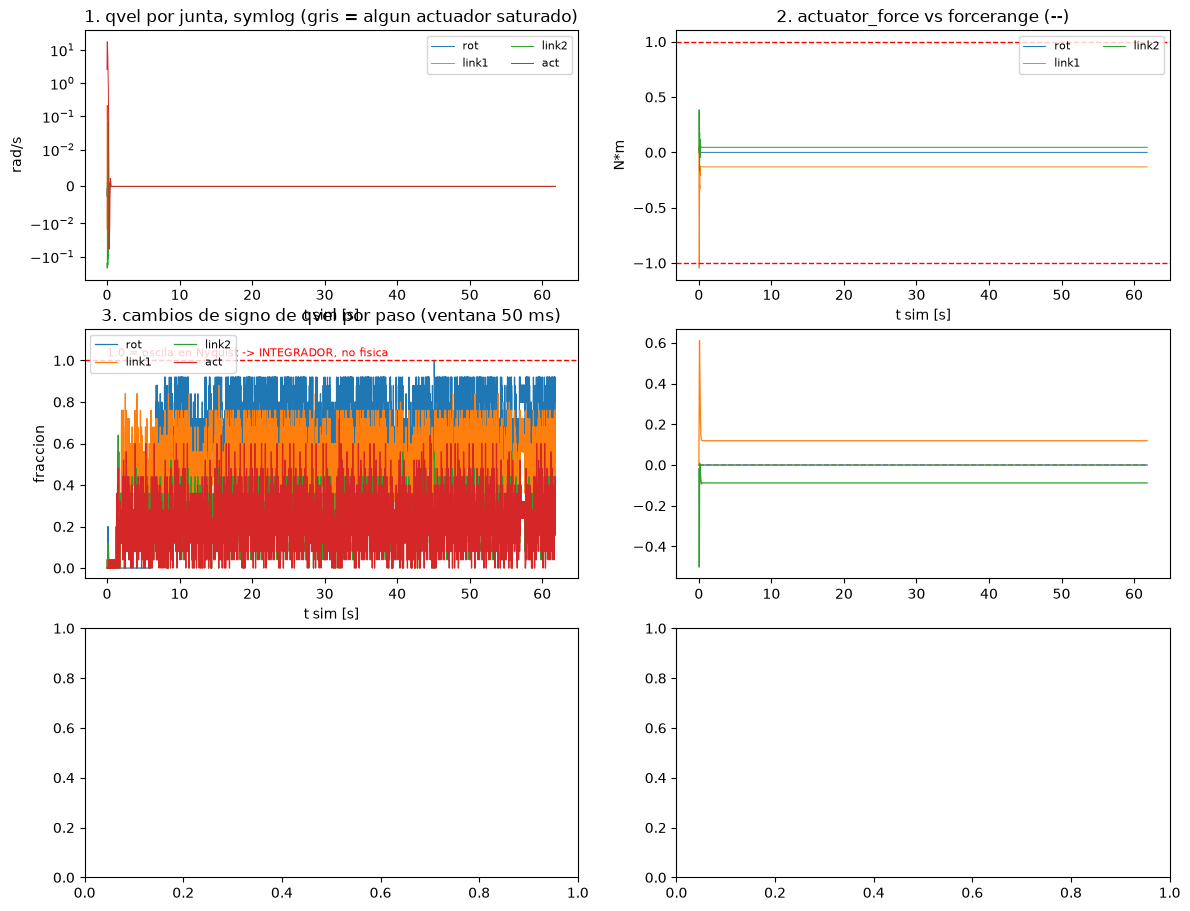

In [76]:
fig = diagnostico_jitter(log)
plt.show()

# Para guardar y comparar dos corridas (p.ej. antes/despues de subir forcerange):
# fig.savefig("jitter_antes.png", dpi=110)

In [ ]:
print(f"masa total del modelo: {model.body_mass.sum():.4f} kg\n")
for b in range(model.nbody):
    if model.body_mass[b] == 0.0:
        continue
    name = mj.mj_id2name(model, mj.mjtObj.mjOBJ_BODY, b)
    print(f"  {name:<12}{model.body_mass[b]:.4f} kg")

masa total del modelo: 0.9689 kg

  base_link   0.3063 kg
  rot         0.1826 kg
  link1       0.1834 kg
  link2       0.2471 kg
  act         0.0495 kg
